---
title: Homework Module 11 — Monte Carlo Estimation of $\pi$
---

*Built with Grok Build*

Course: **EEE591 / EEE419 Python for Rapid Engineering Solutions**.

Estimate $\pi$ by sampling the unit square and counting hits inside the quarter-circle
$x^2+y^2\le 1$. Report success rates across prescribed absolute-error precisions.
With debug enabled, intermediate diagnostics and annotated plots are shown.


In [1]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - HW_M11: HW_M11.py
# Mark Khusid
##########################################################################################

##########################################################################################
# MW_M11
#                    
##########################################################################################


## Import Libraries


In [2]:
import numpy as np
from random import random
import matplotlib.pyplot as plt


## Create Debug Flags


In [3]:
debug = True
debug_lvl_2 = True
print(f"debug = {debug}, debug_lvl_2 = {debug_lvl_2}")


debug = True, debug_lvl_2 = True


## Define Maximum Number of Attempts


In [4]:
MAX_NUM_ATTEMPTS = 100


## Define Maximum Number of Points


In [5]:
MAX_NUM_POINTS = 10_000


## Define Precisions List


In [6]:
precisions_list = [10**(-power) for power in range(1, 8)] # 10^-1 to 10^-7


In [7]:
if debug:
    print(precisions_list)


[0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07]


## Define Estimate_Pi_Attempt() Function


In [8]:
if debug:
    print(random())
    print(type(np.pi))
    print(f"{np.pi:.50f}")
    print(np.finfo(float))


0.9640733765603074
<class 'float'>
3.14159265358979311599796346854418516159057617187500
Machine parameters for float64
---------------------------------------------------------------
precision = 15   resolution = 1e-15
machep = -52   eps =        2.220446049250313e-16
negep =  -53   epsneg =     1.1102230246251565e-16
minexp = -1022   tiny =       2.2250738585072014e-308
maxexp = 1024   max =        1.7976931348623157e+308
nexp =   11   min =        -max
smallest_normal = 2.2250738585072014e-308   smallest_subnormal = 5e-324
---------------------------------------------------------------



In [9]:
################################################################################
# Function to estimate pi using the Monte Carlo method.  Returns the estimate  #
# if successful and returns None if not successfull.                           #
#                                                                              #
# Inputs:                                                                      #
#    precision - the desired precision of the estimate                         #
#                                                                              #
# Outputs:                                                                     #
#    returns the estimate of pi at precision and None if not successful        #
################################################################################

def estimate_pi_attempt(precision):

    # Initialize the counter that holds the number of points that are
    # inside the circle.
    num_points_inside = 0

    # Start estimation loop
    for total_points in range(1, MAX_NUM_POINTS + 1):

        # Generate random values for x and y
        x = random() # Number is between 0 and 1
        y = random() # Number is between 0 and 1

        # Check whether generated points are inside the circle
        # The condition is if the distance from the origin is <= 1
        if (x**2 + y**2) <= 1.0:
            # increment number of points inside circle counter
            num_points_inside += 1

        # Estimate pi up till now
        estimated_pi = 4.0 * num_points_inside / total_points

        # Check whether precision criteria is met
        # if the estimated pi - built in pi is <= precision
        # then return the estimated pi, otherwise return None
        if abs(estimated_pi - np.pi) <= precision:
            return(estimated_pi)

    # Else always return a None for safety
    return None   


In [10]:
if debug:
    print(estimate_pi_attempt(0.001))
    print(estimate_pi_attempt(1e-20))


3.141304347826087
None


## Define Main() Function


In [11]:
def main():

    # Loop through all required precisions in precision_list
    for precision in precisions_list:

        # Create a list of successful pi estimates at the current 
        # precision iteration.  
        successful_values = []

        # Initialize success counter
        success_count = 0
        
        # Loop for MAX_NUM_ATTEMPTS times to estimate pi.
        for attempt in range(MAX_NUM_ATTEMPTS):
            # Try to estimate pi using the estimate_pi_attempt() function
            pi_value = estimate_pi_attempt(precision=precision)

            # If successful, add the pi_value to the successful_values list
            # and increment success counter
            if pi_value is not None:
                successful_values.append(pi_value)
                success_count += 1
                
                # Get level 2 debug info
                if debug_lvl_2:
                    print(f"[*] Hit at {pi_value:.7f}, success_count = {success_count}")

        # Get the average pi value for this precision iteration only if there are successes
        # Print out results per HW requirements
        if success_count > 0:
            average_pi = sum(successful_values) / success_count
            print(f"{precision}, success, {success_count}, times, {average_pi}")
        else:
            print(f"{precision}, no success")

if __name__ == "__main__":
    main()


[*] Hit at 3.2000000, success_count = 1
[*] Hit at 3.2000000, success_count = 2
[*] Hit at 3.2000000, success_count = 3
[*] Hit at 3.2000000, success_count = 4
[*] Hit at 3.2380952, success_count = 5
[*] Hit at 3.2000000, success_count = 6
[*] Hit at 3.1111111, success_count = 7
[*] Hit at 3.2000000, success_count = 8
[*] Hit at 3.1578947, success_count = 9
[*] Hit at 3.2000000, success_count = 10
[*] Hit at 3.1111111, success_count = 11
[*] Hit at 3.1111111, success_count = 12
[*] Hit at 3.1111111, success_count = 13
[*] Hit at 3.0769231, success_count = 14
[*] Hit at 3.1111111, success_count = 15
[*] Hit at 3.2000000, success_count = 16
[*] Hit at 3.1111111, success_count = 17
[*] Hit at 3.0769231, success_count = 18
[*] Hit at 3.2000000, success_count = 19
[*] Hit at 3.2000000, success_count = 20
[*] Hit at 3.1111111, success_count = 21
[*] Hit at 3.2000000, success_count = 22
[*] Hit at 3.0465116, success_count = 23
[*] Hit at 3.0434783, success_count = 24
[*] Hit at 3.2000000, suc

[*] Hit at 3.1415549, success_count = 36
[*] Hit at 3.1416490, success_count = 37
[*] Hit at 3.1416838, success_count = 38
[*] Hit at 3.1415797, success_count = 39
[*] Hit at 3.1415525, success_count = 40
[*] Hit at 3.1415094, success_count = 41
[*] Hit at 3.1415525, success_count = 42
[*] Hit at 3.1415183, success_count = 43
[*] Hit at 3.1415301, success_count = 44
[*] Hit at 3.1415663, success_count = 45
[*] Hit at 3.1414944, success_count = 46
[*] Hit at 3.1416550, success_count = 47
[*] Hit at 3.1416667, success_count = 48
[*] Hit at 3.1415929, success_count = 49
[*] Hit at 3.1415525, success_count = 50
[*] Hit at 3.1415816, success_count = 51
[*] Hit at 3.1415266, success_count = 52
[*] Hit at 3.1415525, success_count = 53
[*] Hit at 3.1415183, success_count = 54
[*] Hit at 3.1416808, success_count = 55
[*] Hit at 3.1415241, success_count = 56
[*] Hit at 3.1416667, success_count = 57
[*] Hit at 3.1416309, success_count = 58
[*] Hit at 3.1415771, success_count = 59
[*] Hit at 3.141

[*] Hit at 3.1415866, success_count = 4
[*] Hit at 3.1415850, success_count = 5
[*] Hit at 3.1415929, success_count = 6
[*] Hit at 3.1416016, success_count = 7
[*] Hit at 3.1415873, success_count = 8
[*] Hit at 3.1415985, success_count = 9
[*] Hit at 3.1416019, success_count = 10
[*] Hit at 3.1415838, success_count = 11
[*] Hit at 3.1415994, success_count = 12
[*] Hit at 3.1415929, success_count = 13
[*] Hit at 3.1415850, success_count = 14
[*] Hit at 3.1415886, success_count = 15
[*] Hit at 3.1416014, success_count = 16
[*] Hit at 3.1415985, success_count = 17
[*] Hit at 3.1415873, success_count = 18
[*] Hit at 3.1415929, success_count = 19
[*] Hit at 3.1415864, success_count = 20
[*] Hit at 3.1415850, success_count = 21
[*] Hit at 3.1415985, success_count = 22


[*] Hit at 3.1415929, success_count = 23
[*] Hit at 3.1415850, success_count = 24
[*] Hit at 3.1415929, success_count = 25
[*] Hit at 3.1415945, success_count = 26
[*] Hit at 3.1416026, success_count = 27
[*] Hit at 3.1416007, success_count = 28
[*] Hit at 3.1415985, success_count = 29
[*] Hit at 3.1415886, success_count = 30
[*] Hit at 3.1415989, success_count = 31
[*] Hit at 3.1415876, success_count = 32
[*] Hit at 3.1415850, success_count = 33
[*] Hit at 3.1415929, success_count = 34
[*] Hit at 3.1415929, success_count = 35
[*] Hit at 3.1415838, success_count = 36


[*] Hit at 3.1415831, success_count = 37
[*] Hit at 3.1415911, success_count = 38
[*] Hit at 3.1416007, success_count = 39
[*] Hit at 3.1415831, success_count = 40
[*] Hit at 3.1416007, success_count = 41
[*] Hit at 3.1415873, success_count = 42
[*] Hit at 3.1415965, success_count = 43
[*] Hit at 3.1415940, success_count = 44
[*] Hit at 3.1415906, success_count = 45
[*] Hit at 3.1415985, success_count = 46
[*] Hit at 3.1415831, success_count = 47
[*] Hit at 3.1415869, success_count = 48
[*] Hit at 3.1415833, success_count = 49
[*] Hit at 3.1415886, success_count = 50
[*] Hit at 3.1416026, success_count = 51
[*] Hit at 3.1415850, success_count = 52
[*] Hit at 3.1415994, success_count = 53
[*] Hit at 3.1415929, success_count = 54
[*] Hit at 3.1415929, success_count = 55
[*] Hit at 3.1415842, success_count = 56
[*] Hit at 3.1415909, success_count = 57
[*] Hit at 3.1415886, success_count = 58
[*] Hit at 3.1415955, success_count = 59


...

[*] Hit at 3.1415929, success_count = 8
[*] Hit at 3.1415929, success_count = 9
[*] Hit at 3.1415929, success_count = 10
[*] Hit at 3.1415929, success_count = 11
[*] Hit at 3.1415929, success_count = 12
[*] Hit at 3.1415929, success_count = 13


[*] Hit at 3.1415929, success_count = 14
[*] Hit at 3.1415929, success_count = 15
[*] Hit at 3.1415929, success_count = 16
[*] Hit at 3.1415929, success_count = 17
[*] Hit at 3.1415929, success_count = 18
[*] Hit at 3.1415919, success_count = 19
[*] Hit at 3.1415929, success_count = 20
[*] Hit at 3.1415929, success_count = 21


[*] Hit at 3.1415929, success_count = 22
[*] Hit at 3.1415929, success_count = 23
[*] Hit at 3.1415929, success_count = 24
[*] Hit at 3.1415929, success_count = 25
[*] Hit at 3.1415929, success_count = 26
[*] Hit at 3.1415929, success_count = 27
[*] Hit at 3.1415929, success_count = 28
[*] Hit at 3.1415929, success_count = 29
[*] Hit at 3.1415929, success_count = 30
[*] Hit at 3.1415920, success_count = 31
[*] Hit at 3.1415929, success_count = 32
[*] Hit at 3.1415929, success_count = 33


1e-06, success, 33, times, 3.141592859294228


1e-07, no success


## Annotated Monte Carlo visualization

Illustrate one quarter-circle sampling run and summarize success counts vs required precision.


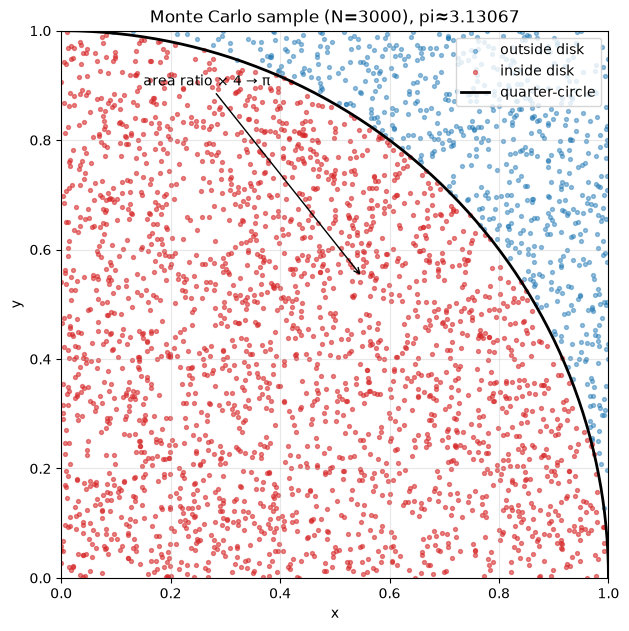

visual run: inside=2348/3000, pi_hat=3.13066667, |err|=1.093e-02


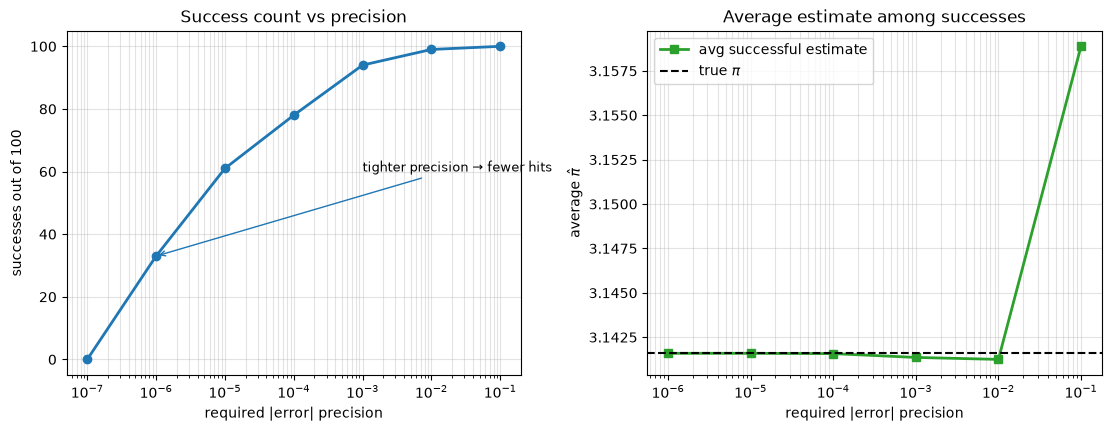

In [12]:
# --- One illustrative MC scatter (quarter unit disk) ---
rng = np.random.default_rng(0)
n_vis = 3000
xs = rng.random(n_vis)
ys = rng.random(n_vis)
inside = xs**2 + ys**2 <= 1.0
pi_hat = 4.0 * np.count_nonzero(inside) / n_vis

fig, ax = plt.subplots(figsize=(6.2, 6.2), constrained_layout=True)
ax.scatter(xs[~inside], ys[~inside], s=8, c="C0", alpha=0.45, label="outside disk")
ax.scatter(xs[inside], ys[inside], s=8, c="C3", alpha=0.55, label="inside disk")
theta = np.linspace(0, np.pi / 2, 200)
ax.plot(np.cos(theta), np.sin(theta), "k-", lw=2, label="quarter-circle")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Monte Carlo sample (N={n_vis}), pi≈{pi_hat:.5f}")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
ax.annotate("area ratio × 4 → π", xy=(0.55, 0.55), xytext=(0.15, 0.9),
            arrowprops=dict(arrowstyle="->", color="k"), fontsize=10)
plt.show()
if debug:
    print(f"visual run: inside={np.count_nonzero(inside)}/{n_vis}, pi_hat={pi_hat:.8f}, |err|={abs(pi_hat-np.pi):.3e}")

# --- Success profile across precisions (re-run summary for plotting) ---
success_counts = []
avg_estimates = []
for precision in precisions_list:
    successful_values = []
    for attempt in range(MAX_NUM_ATTEMPTS):
        pi_value = estimate_pi_attempt(precision=precision)
        if pi_value is not None:
            successful_values.append(pi_value)
    success_counts.append(len(successful_values))
    avg_estimates.append(np.mean(successful_values) if successful_values else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].semilogx(precisions_list, success_counts, "o-", lw=2)
axes[0].set_xlabel("required |error| precision")
axes[0].set_ylabel(f"successes out of {MAX_NUM_ATTEMPTS}")
axes[0].set_title("Success count vs precision")
axes[0].grid(True, which="both", alpha=0.35)
axes[0].annotate("tighter precision → fewer hits",
                 xy=(precisions_list[-2], success_counts[-2]),
                 xytext=(precisions_list[2], max(success_counts)*0.6),
                 arrowprops=dict(arrowstyle="->", color="C0"), fontsize=9)

axes[1].semilogx(precisions_list, avg_estimates, "s-", color="C2", lw=2, label="avg successful estimate")
axes[1].axhline(np.pi, color="k", ls="--", label=r"true $\pi$")
axes[1].set_xlabel("required |error| precision")
axes[1].set_ylabel("average $\hat{\pi}$")
axes[1].set_title("Average estimate among successes")
axes[1].grid(True, which="both", alpha=0.35)
axes[1].legend(loc="best")
plt.show()
